# Exploratory data analysis

### Description of the data in images.csv

The data to be used consists of images from the MNIST database. MNIST is
comprised of grayscale images of handwritten digits. The database contains
images of digits from 0 to 9. Each image has a resolution of 28x28 pixels.
The dataset presents 42,000 images. This is a subset of all data
available in MNIST.

An image of size 28x28 is represented as a sequence of 784 numbers—one number
for each pixel in the image. Each number falls within the range of 0 to 255.
The higher the number, the greater the pixel intensity. A value of 0
corresponds to a completely black pixel, while the maximum value corresponds
to a completely white pixel.

Each image is represented as a row in the images.csv table. The table contains
columns named pixel0, pixel1, and so on up to pixel783, each of which
corresponds to the value of a specific image pixel. The table also includes a
column named label, which contains information about which digit is represented
in the image.

The objective of the project is to use the values from the columns whose names
start with "pixel" to learn how to predict the value in the "label" column.

### Loading and initial exploration of MNIST data

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from IPython.display import display

In [2]:
# Reading data
sns.set(rc={'figure.figsize': (11.7, 8.27)})
data = pd.read_csv('../../data/images.csv')

print(f'Data dimensions: {data.shape}')
print('\nFirst 5 rows of data:')
display(data.head())

Data dimensions: (42000, 785)

First 5 rows of data:


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
# Checking for missing values
missing_values = data.isnull().sum().sum()
print(f'Number of missing values: {missing_values}')

Number of missing values: 0


### Analysis of class distribution (digits 0-9)

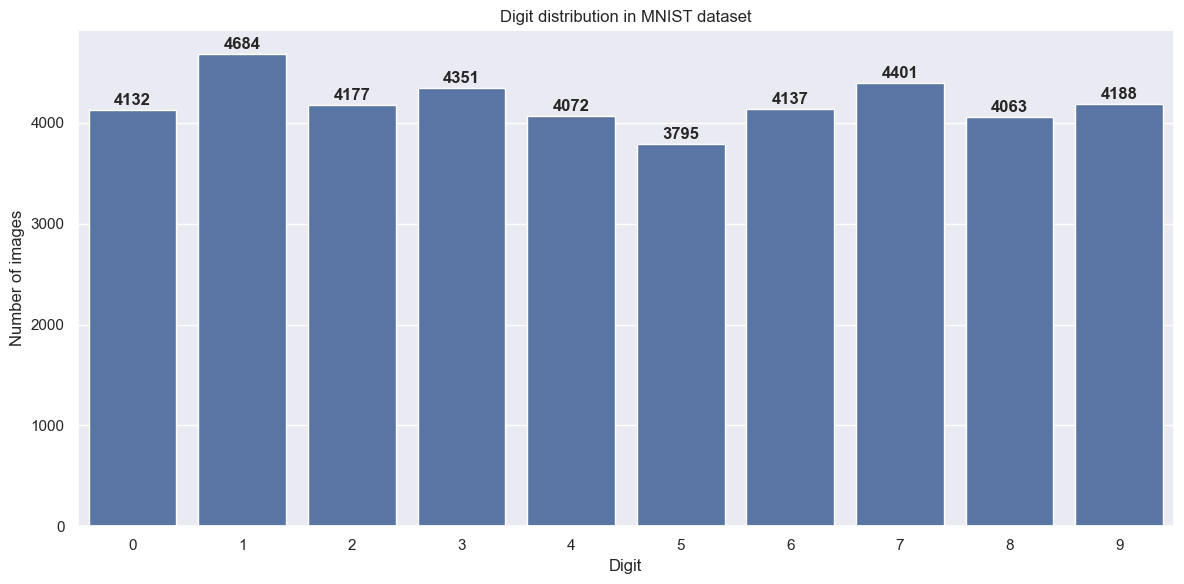

In [4]:
class_distribution = data['label'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=class_distribution.index, y=class_distribution.values)
plt.title('Digit distribution in MNIST dataset')
plt.xlabel('Digit')
plt.ylabel('Number of images')

# Adding values on bars
for i, v in enumerate(class_distribution.values):
    ax.text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

A balanced class distribution is observed, which is a favorable factor for model training.

### Splitting data into training and test sets

In [5]:
x = data.drop(columns='label')
y = data['label']
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=52)

print(f'Training set size: {x_train.shape[0]}')
print(f'Test set size: {x_test.shape[0]}')

Training set size: 33600
Test set size: 8400


### Visualization of image examples

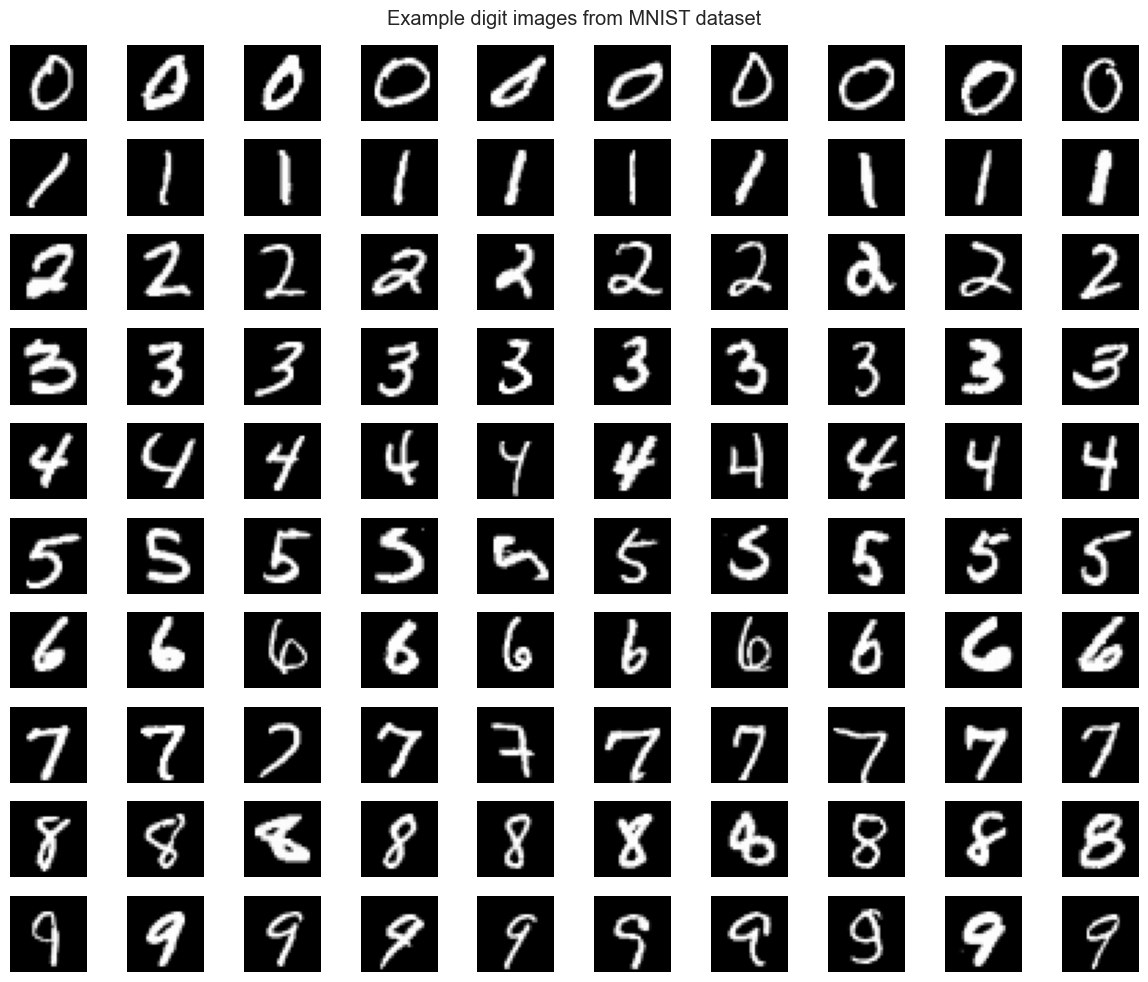

In [6]:
def plot_digit(image_flat, ax=None):
    """Visualizes a single digit image"""
    image = image_flat.reshape(28, 28).astype('uint8')

    if ax is None:
        plt.figure(figsize=(4, 4))
        plt.imshow(image, cmap='gray')
        plt.axis('off')
    else:
        ax.imshow(image, cmap='gray')
        ax.axis('off')

# Creating combined DataFrame with features and labels
x_y_train = x_train.copy(deep=True)
x_y_train['label'] = y_train

# Visualization of 10 random examples for each class
fig, axs = plt.subplots(10, 10, figsize=(12, 10), sharex=True, sharey=True)
group_n = 0
for _, group in x_y_train.groupby('label', as_index=False):
    random_numbers = group.sample(10).drop(columns='label')
    image_vects = [x.values for _, x in random_numbers.iterrows()]

    image_n = 0
    for image in image_vects:
        plot_digit(image, ax=axs[group_n][image_n])
        image_n += 1

    group_n += 1

plt.suptitle('Example digit images from MNIST dataset')
plt.tight_layout()
plt.show()

The presence of many variations of the same digits in the training dataset allows the model to identify various features and abstract from individual handwriting characteristics. This directly contributes to improving the model's quality metrics.

### Analysis of pixel statistical characteristics

In [7]:
# Pixel statistics
pixel_stats = x_train.describe()
print('Pixel statistics:')
display(pixel_stats.loc[['mean', 'std', 'min', 'max']].T)

Pixel statistics:


,mean,std,min,max
pixel0,0.000000,0.00000,0.0,0.0
pixel1,0.000000,0.00000,0.0,0.0
pixel2,0.000000,0.00000,0.0,0.0
pixel3,0.000000,0.00000,0.0,0.0
pixel4,0.000000,0.00000,0.0,0.0
...,...,...,...,...
pixel779,0.003571,0.46316,0.0,62.0
pixel780,0.000000,0.00000,0.0,0.0
pixel781,0.000000,0.00000,0.0,0.0
pixel782,0.000000,0.00000,0.0,0.0


Analysis of pixel distribution revealed a significant spread of values. However, we will neglect normalization since the data is already in the standard range [0, 255].

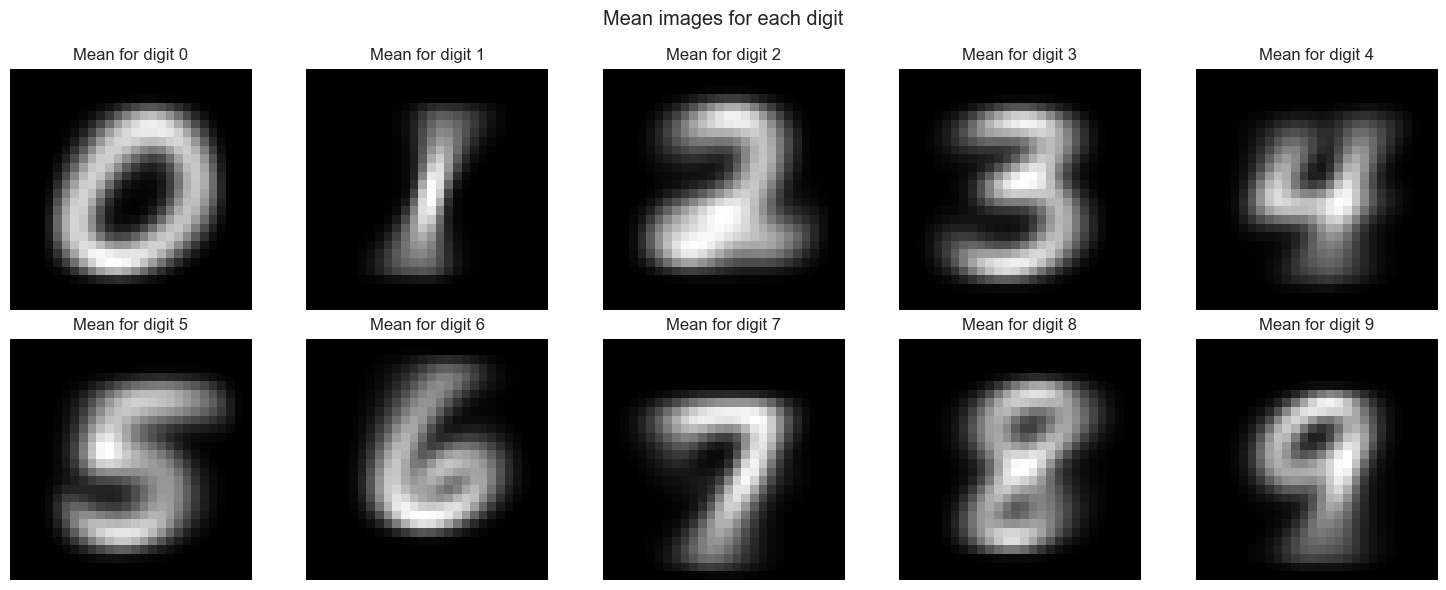

In [8]:
# Analysis of mean pixel values for each digit
mean_digits = []
for digit in range(10):
    digit_mean = x_train[y_train == digit].mean().values.reshape(28, 28)
    mean_digits.append(digit_mean)

# Visualization of mean images for each digit
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for digit in range(10):
    axes[digit].imshow(mean_digits[digit], cmap='gray')
    axes[digit].set_title(f'Mean for digit {digit}')
    axes[digit].axis('off')

plt.suptitle('Mean images for each digit')
plt.tight_layout()
plt.show()

Averaged images visualize the most characteristic features of digits, forming their reference representation. This helps identify key patterns that the model should learn to recognize.

### Analysis of pixel variability

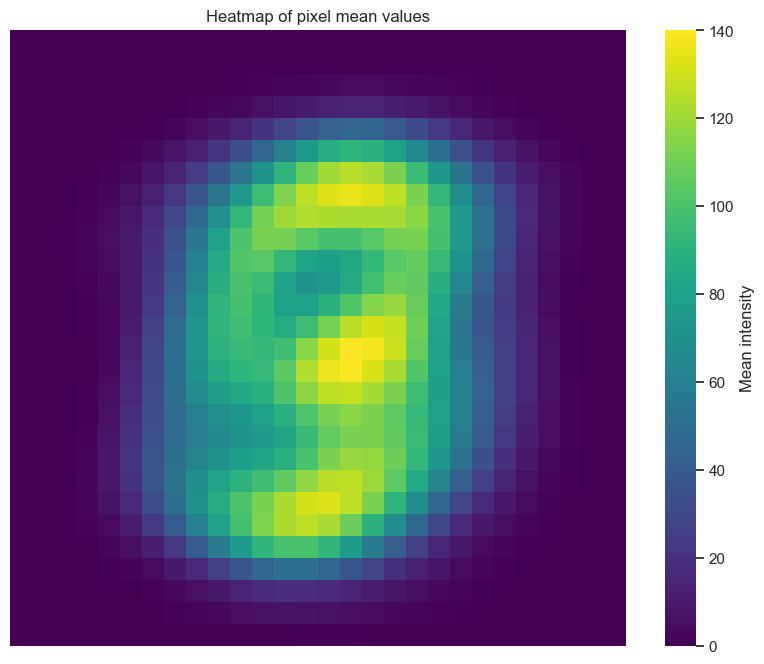

In [9]:
# Heatmap of pixel mean values
plt.figure(figsize=(10, 8))
sns.heatmap(pixel_stats.loc['mean'].values.reshape(28, 28), cmap='viridis',
            square=True, cbar_kws={'label': 'Mean intensity'})
plt.title('Heatmap of pixel mean values')
plt.axis('off')
plt.show()

Analysis of the heatmap of mean pixel values reveals three statistically significant clusters, as well as a general outline defining the typical area where the digit is located.

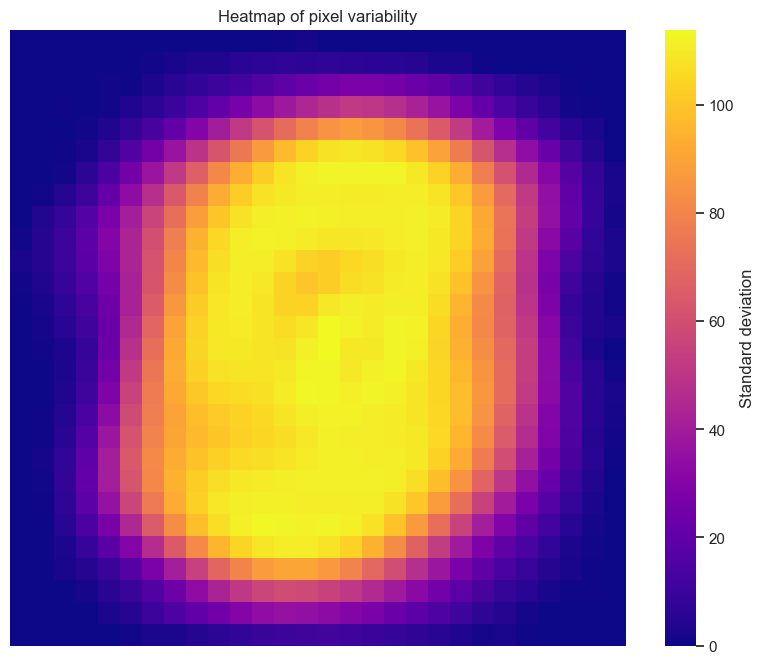

In [10]:
# Heatmap of pixel standard deviations
plt.figure(figsize=(10, 8))
sns.heatmap(pixel_stats.loc['std'].values.reshape(28, 28), cmap='plasma',
            square=True, cbar_kws={'label': 'Standard deviation'})
plt.title('Heatmap of pixel variability')
plt.axis('off')
plt.show()

Analysis of the variability heatmap confirms that the maximum pixel variance is concentrated in the center of the image — in the area where the digits are located. Peripheral pixels, on the other hand, show low variance, allowing them to be classified as low-informative. This indicates a potential opportunity to reduce data dimensionality without loss of model quality.

### Informative feature (pixel) selection

Processing data represented as image pixels is quite complex in our case, and there is no obvious approach to working with them. Nevertheless, as an experiment, we will try to discard low-variance pixels.

In [11]:
# Analysis of pixels with low variability
low_variance_pixels = (pixel_stats.loc['std'] < 5).sum()
percent_low_variance_pixels = low_variance_pixels / 784 * 100
print('Informative feature selection:')
print(f'Number of pixels with low variability: {low_variance_pixels}')
print(f'Percentage of low-variance pixels: {percent_low_variance_pixels:.1f}%')

Informative feature selection:
Number of pixels with low variability: 200
Percentage of low-variance pixels: 25.5%


In [12]:
# Feature selection based on variance threshold
selector = VarianceThreshold(threshold=0.1)
selector.fit(x_train)

# Analysis of selected features
selected_features = selector.get_feature_names_out()
print(f'Total features: {x_train.shape[1]}')
print(f'Selected informative features: {len(selected_features)}')

Total features: 784
Selected informative features: 686


In [13]:
# Applying feature selection
x_train_selected = x_train[selected_features]
x_test_selected = x_test[selected_features]

print('Dimensions after feature selection:')
print(f'Training set: {x_train_selected.shape}')
print(f'Test set: {x_test_selected.shape}')

Dimensions after feature selection:
Training set: (33600, 686)
Test set: (8400, 686)


In [14]:
print('First 5 rows of optimized data:')
display(x_train_selected.head())

First 5 rows of optimized data:


,pixel12,pixel13,pixel34,pixel35,pixel36,pixel37,pixel38,pixel39,pixel40,pixel41,...,pixel770,pixel771,pixel772,pixel773,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779
12344,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
29680,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
21707,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
23136,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
18746,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Model creation and training

In [15]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

### Data loading and preparation

In [16]:
# Reading data
x_train = x_train_selected
y_train = y_train
x_test = x_test_selected
y_test = y_test

print(f'Training set size: {x_train.shape}')
print(f'Test set size: {x_test.shape}')

Training set size: (33600, 686)
Test set size: (8400, 686)


In [17]:
# Determining image size based on selected pixels
n_pixels = x_train.shape[1]
# Nearest square size
img_size = int(np.sqrt(n_pixels))
print(f'Assumed image size: {img_size}x{img_size} = '
      f'{img_size ** 2} pixels')
print(f'Actual number of pixels: {n_pixels} (out of 784 possible)')

Assumed image size: 26x26 = 676 pixels
Actual number of pixels: 686 (out of 784 possible)


In [18]:
# Splitting data into training and validation sets (80%:20%)
x_train_split, x_val, y_train_split, y_val = train_test_split(
    x_train, y_train, test_size=0.2, random_state=52)

print(f'Training set size: {x_train_split.shape}')
print(f'Validation set size: {x_val.shape}')

Training set size: (26880, 686)
Validation set size: (6720, 686)


In [19]:
def print_image(pixels, ax=None, title=None, original_size=28):
    """Visualizes an image from a pixel array considering reduced
    dimensionality"""
    if ax is None:
        fig, ax = plt.subplots(figsize=(3, 3))

    # Creating an array of zeros with size 28x28 = 784 pixels (for the image)
    full_image = np.zeros(original_size ** 2)

    # Filling only those pixels that are present in the final data (pixel name
    # format in data - "pixelX", where X is a number)
    pixel_indices = []
    for col in x_train.columns:
        if col.startswith('pixel'):
            try:
                # Extracting pixel number from the name
                idx = int(col[5:])
                pixel_indices.append(idx)
            except ValueError:
                continue

    # Sorting indices and filling values
    pixel_indices.sort()
    for i, pixel_idx in enumerate(pixel_indices[:len(pixels)]):
        if pixel_idx < len(full_image):
            full_image[pixel_idx] = pixels[i]

    # Converting linear array to 28x28 matrix
    image = full_image.reshape(original_size, original_size)
    # Setting appearance
    ax.imshow(image, cmap='gray')
    ax.set_xticks([])
    ax.set_yticks([])
    if title:
        ax.set_title(title)

    return ax

### Model creation and training

To solve the problem, we will train six models with different hyperparameters: three decision trees and three random forests. In the end, the best model will be selected based on the highest results on quality metrics.

In [20]:
# Dictionary of all models and their results
models_results = {}

# Decision trees with different hyperparameters
min_samples_leaf_values = [1, 3, 5, 10]

print('Training decision trees...')
for min_leaf in min_samples_leaf_values:
    print(f'\nTraining DecisionTree (min_samples_leaf={min_leaf})...')
    print(f'Model name: DT_leaf_{min_leaf}')

    # Creating and training the model
    model_dt = DecisionTreeClassifier(min_samples_leaf=min_leaf,
                                      criterion='gini', random_state=52)
    model_dt.fit(x_train_split, y_train_split)

    # Model predictions
    train_pred = model_dt.predict(x_train_split)
    val_pred = model_dt.predict(x_val)

    # Model accuracy
    train_accuracy = accuracy_score(y_train_split, train_pred)
    val_accuracy = accuracy_score(y_val, val_pred)

    # Saving data to the dictionary of all models
    models_results[f'DT_leaf_{min_leaf}'] = {
        'model': model_dt,
        'train_accuracy': train_accuracy,
        'val_accuracy': val_accuracy
    }

    print(f'Model accuracy on training set: {train_accuracy}')
    print(f'Model accuracy on validation set: {val_accuracy}')
    print(f'Accuracy difference: {train_accuracy - val_accuracy}')

Training decision trees...

Training DecisionTree (min_samples_leaf=1)...
Model name: DT_leaf_1
Model accuracy on training set: 1.0
Model accuracy on validation set: 0.843452380952381
Accuracy difference: 0.15654761904761905

Training DecisionTree (min_samples_leaf=3)...
Model name: DT_leaf_3
Model accuracy on training set: 0.9581473214285714
Model accuracy on validation set: 0.8398809523809524
Accuracy difference: 0.118266369047619

Training DecisionTree (min_samples_leaf=5)...
Model name: DT_leaf_5
Model accuracy on training set: 0.9375744047619048
Model accuracy on validation set: 0.8464285714285714
Accuracy difference: 0.09114583333333337

Training DecisionTree (min_samples_leaf=10)...
Model name: DT_leaf_10
Model accuracy on training set: 0.9053943452380953
Model accuracy on validation set: 0.8340773809523809
Accuracy difference: 0.07131696428571432


In [21]:
# Random forest with different hyperparameters
n_estimators_values = [100, 300, 500, 1000]

print('Training random forest...')
for n_est in n_estimators_values:
    print(f'\nTraining RandomForest (n_estimators={n_est})...')
    print(f'Model name: RF_est_{n_est}')

    # Creating and training the model
    model_rf = RandomForestClassifier(n_estimators=n_est, min_samples_leaf=3,
                                      max_features='sqrt', criterion='gini',
                                      random_state=52, n_jobs=-1)
    model_rf.fit(x_train_split, y_train_split)

    # Model predictions
    train_pred = model_rf.predict(x_train_split)
    val_pred = model_rf.predict(x_val)

    # Model accuracy
    train_accuracy = accuracy_score(y_train_split, train_pred)
    val_accuracy = accuracy_score(y_val, val_pred)

    # Saving data to the dictionary of all models
    models_results[f'RF_est_{n_est}'] = {
        'model': model_rf,
        'train_accuracy': train_accuracy,
        'val_accuracy': val_accuracy
    }

    print(f'Model accuracy on training set: {train_accuracy}')
    print(f'Model accuracy on validation set: {val_accuracy}')
    print(f'Accuracy difference: {train_accuracy - val_accuracy}')

Training random forest...

Training RandomForest (n_estimators=100)...
Model name: RF_est_100
Model accuracy on training set: 0.996875
Model accuracy on validation set: 0.9583333333333334
Accuracy difference: 0.038541666666666585

Training RandomForest (n_estimators=300)...
Model name: RF_est_300
Model accuracy on training set: 0.9969866071428571
Model accuracy on validation set: 0.9607142857142857
Accuracy difference: 0.0362723214285714

Training RandomForest (n_estimators=500)...
Model name: RF_est_500
Model accuracy on training set: 0.9973214285714286
Model accuracy on validation set: 0.9602678571428571
Accuracy difference: 0.03705357142857146

Training RandomForest (n_estimators=1000)...
Model name: RF_est_1000
Model accuracy on training set: 0.9972098214285714
Model accuracy on validation set: 0.9617559523809524
Accuracy difference: 0.03545386904761905


### Selecting the best model for further analysis

In [22]:
best_model_name = max(models_results.keys(),
                      key=lambda x: models_results[x]['val_accuracy'])
best_model = models_results[best_model_name]['model']

print(f'Best model: {best_model_name}')
print(f'Accuracy on validation set: {models_results[
    best_model_name]['val_accuracy']}')

Best model: RF_est_1000
Accuracy on validation set: 0.9617559523809524


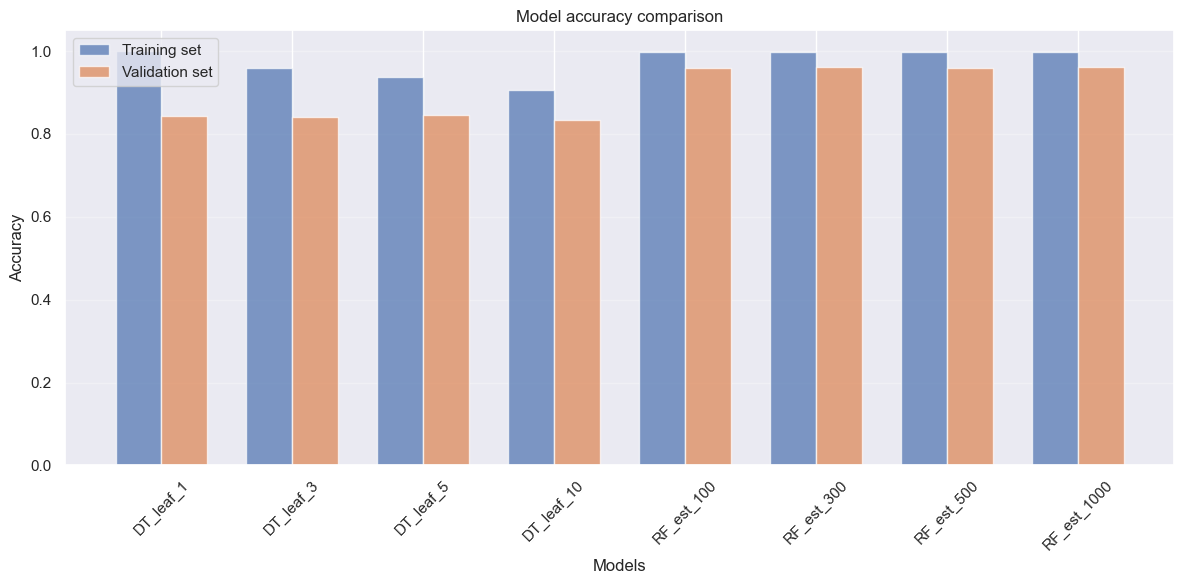

In [23]:
# Model comparison visualization
sns.set(rc={'figure.figsize': (11.7, 8.27)})
plt.figure(figsize=(12, 6))
models_names = list(models_results.keys())
list_train_accuracy = [models_results[name]['train_accuracy']
                       for name in models_names]
list_val_accuracy = [models_results[name]['val_accuracy']
                     for name in models_names]

x_pos = np.arange(len(models_names))
width = 0.35
plt.bar(x_pos - width / 2, list_train_accuracy, width,
        label='Training set', alpha=0.7)
plt.bar(x_pos + width / 2, list_val_accuracy, width,
        label='Validation set', alpha=0.7)

plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model accuracy comparison')
plt.xticks(x_pos, models_names, rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Random forest models on average demonstrate higher accuracy on the validation set compared to decision trees. At the same time, the difference in accuracy between the random forest models themselves is insignificant.

### Evaluating the best model on the validation set

In [24]:
best_val_pred = best_model.predict(x_val)

# Model quality metrics
best_val_accuracy = accuracy_score(y_val, best_val_pred)
best_val_precision = precision_score(y_val, best_val_pred,
                                     average='weighted', zero_division=0)
best_val_recall = recall_score(y_val, best_val_pred,
                               average='weighted', zero_division=0)
best_val_f1 = f1_score(y_val, best_val_pred,
                       average='weighted', zero_division=0)

print(f'Quality metrics of model {best_model_name} on validation set:')
print(f'Accuracy: {best_val_accuracy}')
print(f'Precision: {best_val_precision}')
print(f'Recall: {best_val_recall}')
print(f'F1-score: {best_val_f1}')

Quality metrics of model RF_est_1000 on validation set:
Accuracy: 0.9617559523809524
Precision: 0.961737322842056
Recall: 0.9617559523809524
F1-score: 0.9616897890588718


The best model demonstrates consistently high classification quality: all key quality metrics (Accuracy, Precision, Recall, F1-score) steadily exceed 96%. The results indicate its reliability in digit recognition.

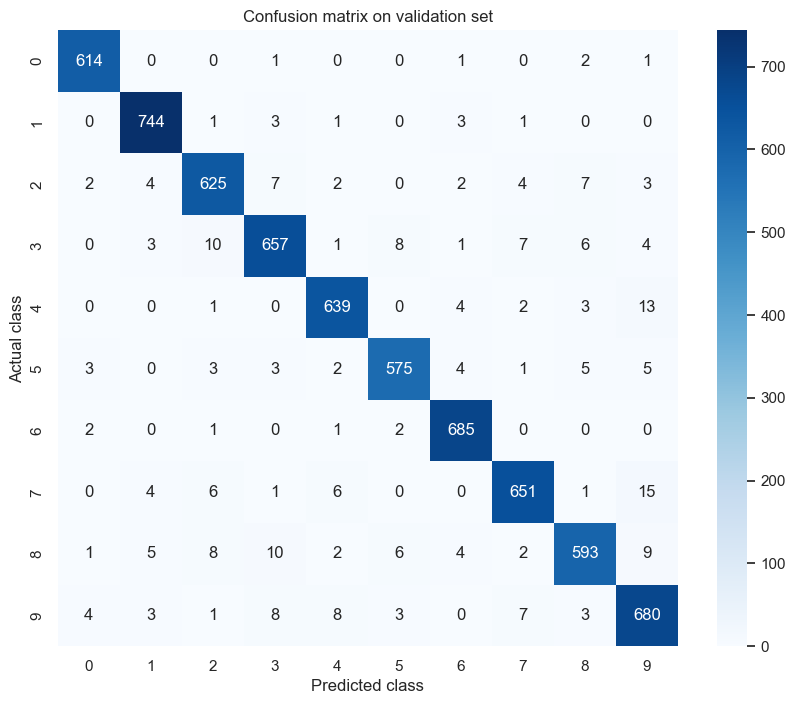

In [25]:
# Confusion matrix visualization
cm = confusion_matrix(y_val, best_val_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion matrix on validation set')
plt.xlabel('Predicted class')
plt.ylabel('Actual class')
plt.show()

The confusion matrix confirms the high effectiveness of the model in digit recognition. Most values are concentrated on the main diagonal, which indicates a minimal number of classification errors.

### Error analysis of the best model on the validation set

In [26]:
error_mask = best_val_pred != y_val
x_errors =  x_val[error_mask]
y_errors_true = y_val[error_mask]
y_errors_pred = best_val_pred[error_mask]

print(f'Number of errors: {len(x_errors)}')
print(f'Error rate: {len(x_errors) / len(y_val):.4f}')

Number of errors: 257
Error rate: 0.0382


In [27]:
# Analysis of most frequent errors
error_counts = pd.DataFrame({
    'true': y_errors_true,
    'pred': y_errors_pred
}).value_counts().head(10).reset_index()
error_counts.columns = ['True Class', 'Predicted Class', 'Count']

print(f'Most frequent errors:')
display(error_counts.reset_index(drop=True))

Most frequent errors:


,True Class,Predicted Class,Count
0,7,9,15
1,4,9,13
2,8,3,10
3,3,2,10
4,8,9,9
5,9,4,8
6,8,2,8
7,3,5,8
8,9,3,8
9,2,3,7


Analysis of the error table allows us to identify the most frequent cases of misclassification. For an in-depth study of the reasons for these errors, we will visualize the most common examples.

Visualizing errors 7 -> 9 (count: 15)


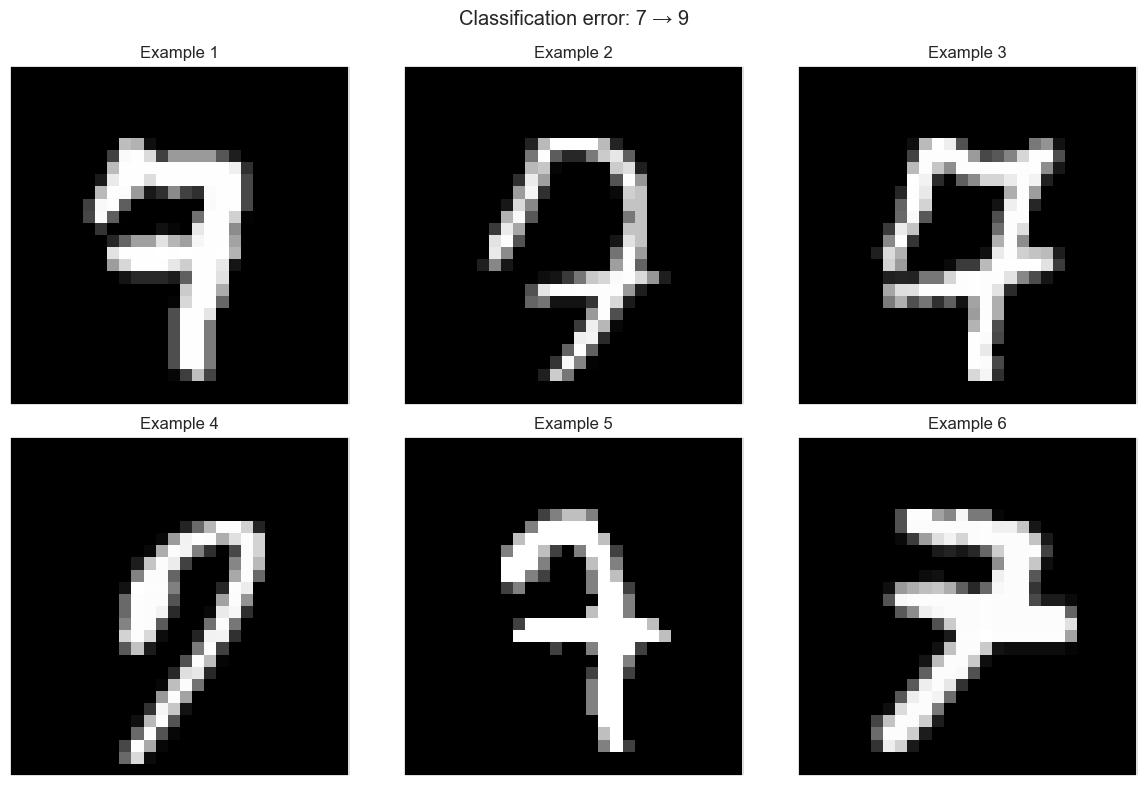

Visualizing errors 4 -> 9 (count: 13)


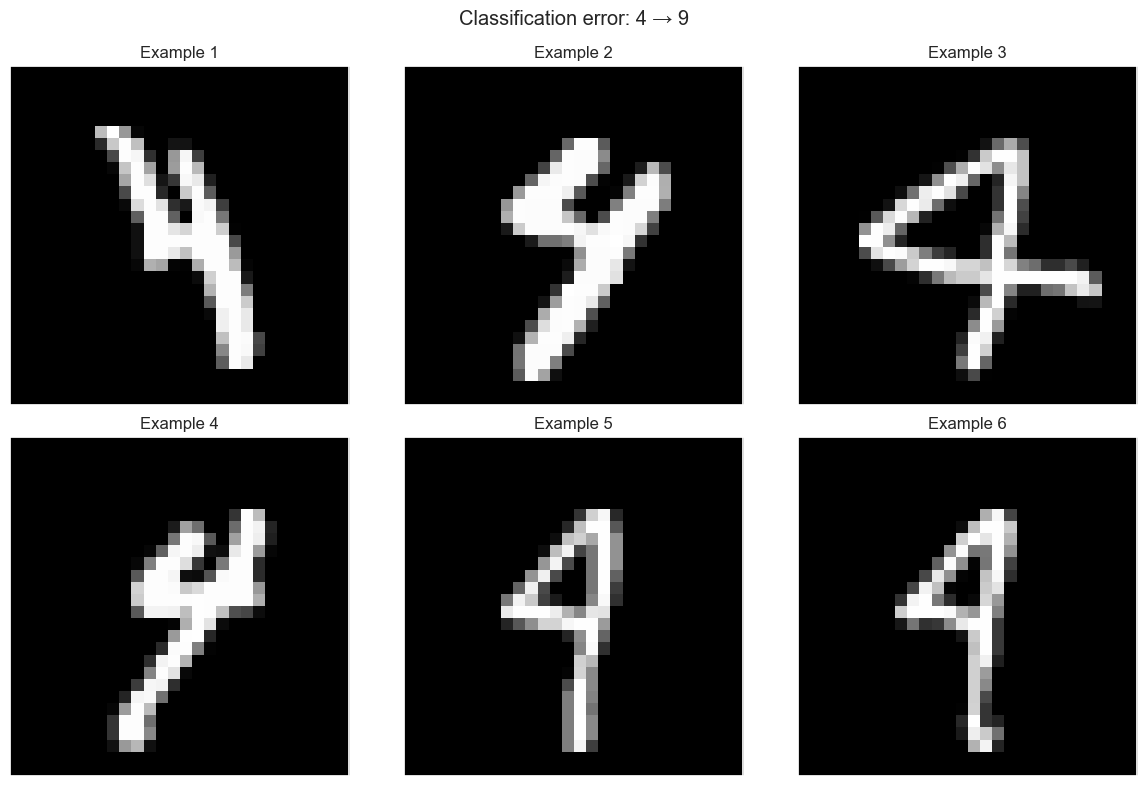

Visualizing errors 8 -> 3 (count: 10)


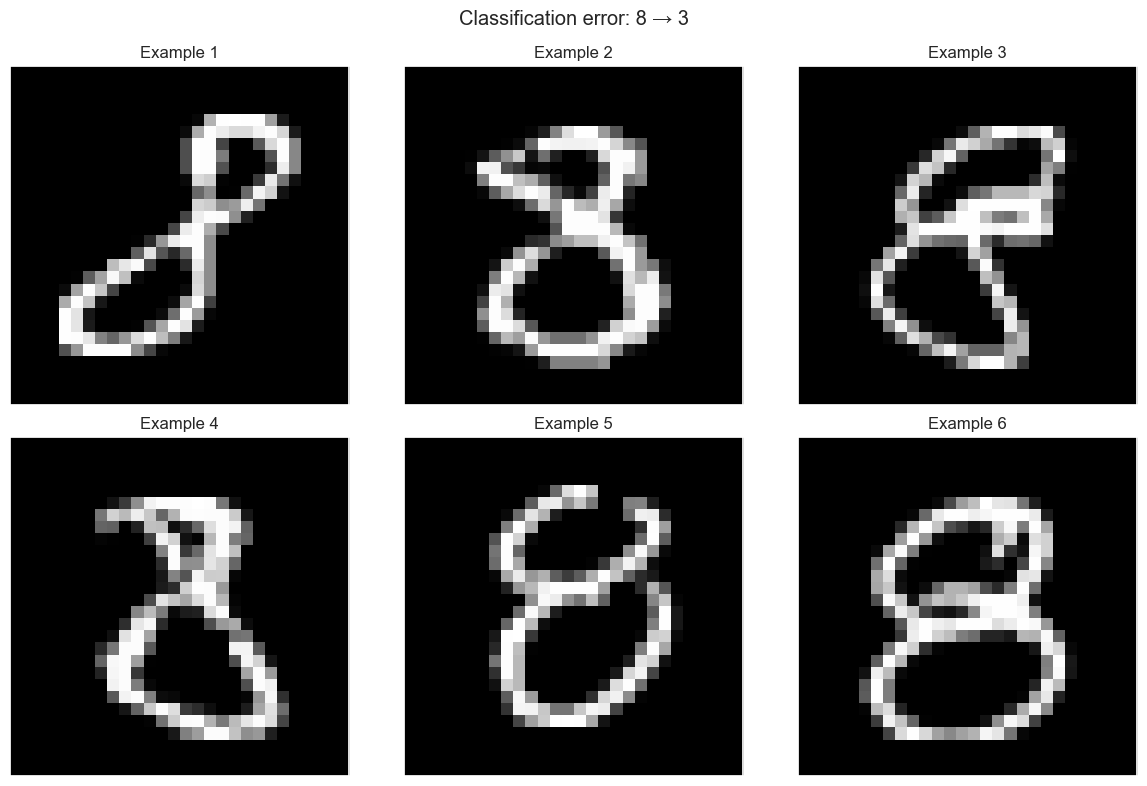

Visualizing errors 3 -> 2 (count: 10)


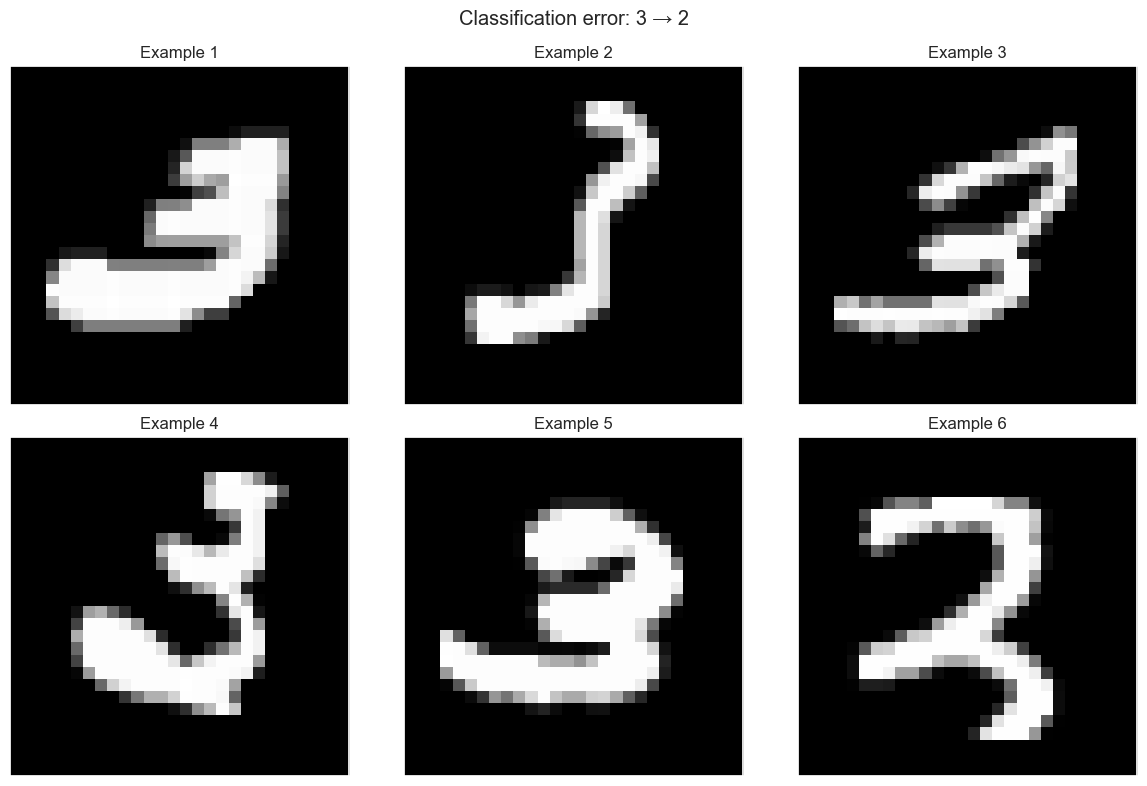

Visualizing errors 8 -> 9 (count: 9)


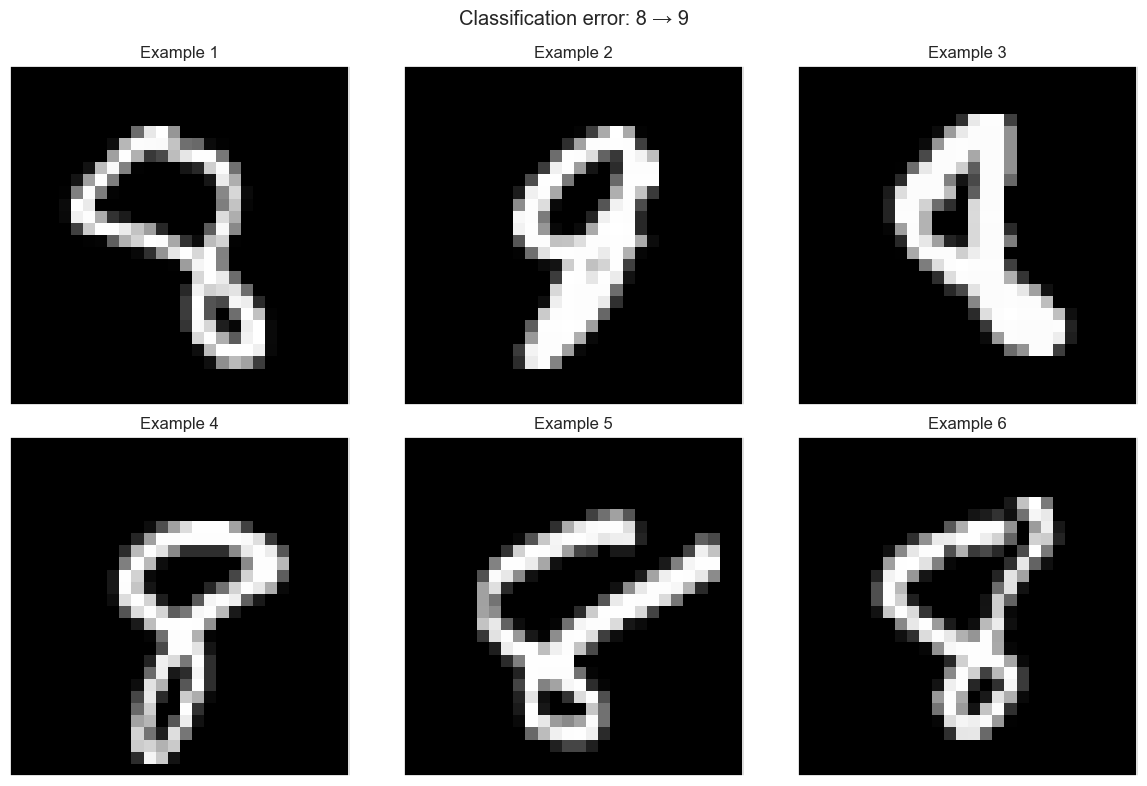

In [28]:
# Error examples visualization
if len(error_counts) > 0:
    # Selecting 5 most frequent errors
    common_errors = error_counts.head(5)

    for i in range(len(common_errors)):
        true_class = common_errors.iloc[i]['True Class']
        pred_class = common_errors.iloc[i]['Predicted Class']
        count = common_errors.iloc[i]['Count']

        print(f'Visualizing errors {true_class} -> {pred_class} '
              f'(count: {count})')

        # Finding examples of this error
        error_indices = np.where(
            (y_errors_true == true_class) & (y_errors_pred == pred_class))[0]

        # Selecting no more than 6 error examples
        examples_to_show = min(6, len(error_indices))

        # Separate plot for each error
        n_cols = 3
        n_rows = (examples_to_show + n_cols - 1) // n_cols
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
        # Converting axes to array for consistency if there's only one row
        if n_rows == 1:
            axes = axes.reshape(1, -1)
        elif n_cols == 1:
            axes = axes.reshape(-1, 1)
        plot_idx = 0

        for j in range(examples_to_show):
            idx = error_indices[j]
            actual_idx = x_errors.index[idx]
            pixels = x_val.loc[actual_idx].values

            # Calculating subplot coordinates
            row = plot_idx // n_cols
            col = plot_idx % n_cols

            ax = print_image(pixels=pixels, ax=axes[row, col],
                             title=f'Example {j+1}')
            plot_idx += 1

        # Hiding unused subplots
        for k in range(plot_idx, n_rows * n_cols):
            row = k // n_cols
            col = k % n_cols
            axes[row, col].set_visible(False)

        fig.suptitle(f'Classification error: {true_class} → {pred_class}')
        plt.tight_layout()
        plt.show()
else:
    print('No errors to visualize!')

Analysis of classification errors revealed two main groups. The first is errors due to overlapping features in the data, where digits are objectively similar. The second, more problematic group, is errors without a visible pattern. Their presence indicates that the current model has likely reached its limit. This points to a potential direction for improvement — using a more complex architecture.

### Evaluating the best model on the test set

In [29]:
best_test_pred = best_model.predict(x_test)

best_test_accuracy = accuracy_score(y_test, best_test_pred)
best_test_precision = precision_score(y_test, best_test_pred,
                                      average='weighted', zero_division=0)
best_test_recall = recall_score(y_test, best_test_pred,
                                average='weighted', zero_division=0)
best_test_f1 = f1_score(y_test, best_test_pred,
                        average='weighted', zero_division=0)

print(f'Quality metrics of model {best_model_name} on test set:')
print(f'Accuracy: {best_test_accuracy}')
print(f'Precision: {best_test_precision}')
print(f'Recall: {best_test_recall}')
print(f'F1-score: {best_test_f1}')

Quality metrics of model RF_est_1000 on test set:
Accuracy: 0.9576190476190476
Precision: 0.9576405928911773
Recall: 0.9576190476190476
F1-score: 0.9576117218040346


The similarity of quality metrics on the validation and test sets indicates the absence of model overfitting.

In [30]:
print('Classification report:')
report = classification_report(y_test, best_test_pred, zero_division=0,
                               output_dict=True)
display(pd.DataFrame(report).transpose())

Classification report:


,precision,recall,f1-score,support
0,0.975806,0.989486,0.982599,856.000000
1,0.984649,0.980349,0.982495,916.000000
2,0.945813,0.952854,0.949320,806.000000
3,0.937639,0.934517,0.936076,901.000000
4,0.962740,0.968561,0.965642,827.000000
5,0.948993,0.952830,0.950908,742.000000
6,0.977860,0.974265,0.976059,816.000000
7,0.967705,0.949095,0.958310,884.000000
8,0.944511,0.943373,0.943942,830.000000
9,0.927184,0.929440,0.928311,822.000000


The model demonstrates high and balanced effectiveness, as evidenced by the overall accuracy of 95.76%. The model shows the best results for digits 0, 1, and 6, where F1-score values exceed 97%. A slight decrease in performance is observed for digits 9, 3, and 8, which are likely the most difficult to classify. At the same time, the difference between macro avg and weighted avg is insignificant, indicating uniform prediction quality across all classes.

### Bootstrap for confidence intervals of quality metrics

In [31]:
# Combining test data
x_y_test = x_test.copy(deep=True)
x_y_test['label'] = y_test

boot_accuracies = []
boot_precisions = []
boot_recalls = []
boot_f1_scores = []

n_bootstraps = 1000

print(f'Running bootstrap ({n_bootstraps} iterations)...')
for i in range(n_bootstraps):
    if (i + 1) % 100 == 0:
        print(f'Completed iterations: {i + 1}/{n_bootstraps}')

    # Creating bootstrap sample
    x_y_test_boot = x_y_test.sample(len(x_y_test), replace=True)
    x_test_boot = x_y_test_boot.drop(columns='label')
    y_test_boot = x_y_test_boot['label']

    # Model predictions
    y_pred = best_model.predict(x_test_boot)

    # Calculating quality metrics
    boot_accuracies.append(accuracy_score(y_test_boot, y_pred))
    boot_precisions.append(precision_score(y_test_boot, y_pred,
                                         average='weighted', zero_division=0))
    boot_recalls.append(recall_score(y_test_boot, y_pred,
                                   average='weighted', zero_division=0))
    boot_f1_scores.append(f1_score(y_test_boot, y_pred,
                                 average='weighted', zero_division=0))

def calculate_confidence_interval(metric_values):
    """Calculates confidence intervals (95%)"""
    sorted_metrics = np.sort(metric_values)
    lower_bound = sorted_metrics[int(0.025 * len(sorted_metrics))]
    upper_bound = sorted_metrics[int(0.975 * len(sorted_metrics))]
    return lower_bound, upper_bound

accuracy_ci = calculate_confidence_interval(boot_accuracies)
precision_ci = calculate_confidence_interval(boot_precisions)
recall_ci = calculate_confidence_interval(boot_recalls)
f1_ci = calculate_confidence_interval(boot_f1_scores)

Running bootstrap (1000 iterations)...
Completed iterations: 100/1000
Completed iterations: 200/1000
Completed iterations: 300/1000
Completed iterations: 400/1000
Completed iterations: 500/1000
Completed iterations: 600/1000
Completed iterations: 700/1000
Completed iterations: 800/1000
Completed iterations: 900/1000
Completed iterations: 1000/1000


In [32]:
# Output confidence intervals
print('Confidence intervals of metrics (bootstrap):')
print('Accuracy:')
print(f'Interval mean value: {best_test_accuracy}')
print(f'Interval: [{accuracy_ci[0]}, {accuracy_ci[1]}]')
print(f'Interval description: (95% CI, width: {
    accuracy_ci[1] - accuracy_ci[0]})')

print('\nPrecision:')
print(f'Interval mean value: {best_test_precision}')
print(f'Interval: [{precision_ci[0]}, {precision_ci[1]}]')
print(f'Interval description: (95% CI, width: {
    precision_ci[1] - precision_ci[0]})')

print('\nRecall:')
print(f'Interval mean value: {best_test_recall}')
print(f'Interval: [{recall_ci[0]}, {recall_ci[1]}]')
print(f'Interval description: (95% CI, width: {recall_ci[1] - recall_ci[0]})')

print('\nF1:')
print(f'Interval mean value: {best_test_f1}')
print(f'Interval: [{f1_ci[0]}, {f1_ci[1]}]')
print(f'Interval description: (95% CI, width: {f1_ci[1] - f1_ci[0]})')

Confidence intervals of metrics (bootstrap):
Accuracy:
Interval mean value: 0.9576190476190476
Interval: [0.9533333333333334, 0.9617857142857142]
Interval description: (95% CI, width: 0.008452380952380878)

Precision:
Interval mean value: 0.9576405928911773
Interval: [0.9533598762260477, 0.9618341840732598]
Interval description: (95% CI, width: 0.008474307847212148)

Recall:
Interval mean value: 0.9576190476190476
Interval: [0.9533333333333334, 0.9617857142857142]
Interval description: (95% CI, width: 0.008452380952380878)

F1:
Interval mean value: 0.9576117218040346
Interval: [0.9533048546771972, 0.9617710618278564]
Interval description: (95% CI, width: 0.008466207150659266)


Narrow confidence intervals for all quality metrics confirm the high stability and reliability of the model. This excludes overfitting and proves that the quality assessment on the test set objectively reflects the model's performance.

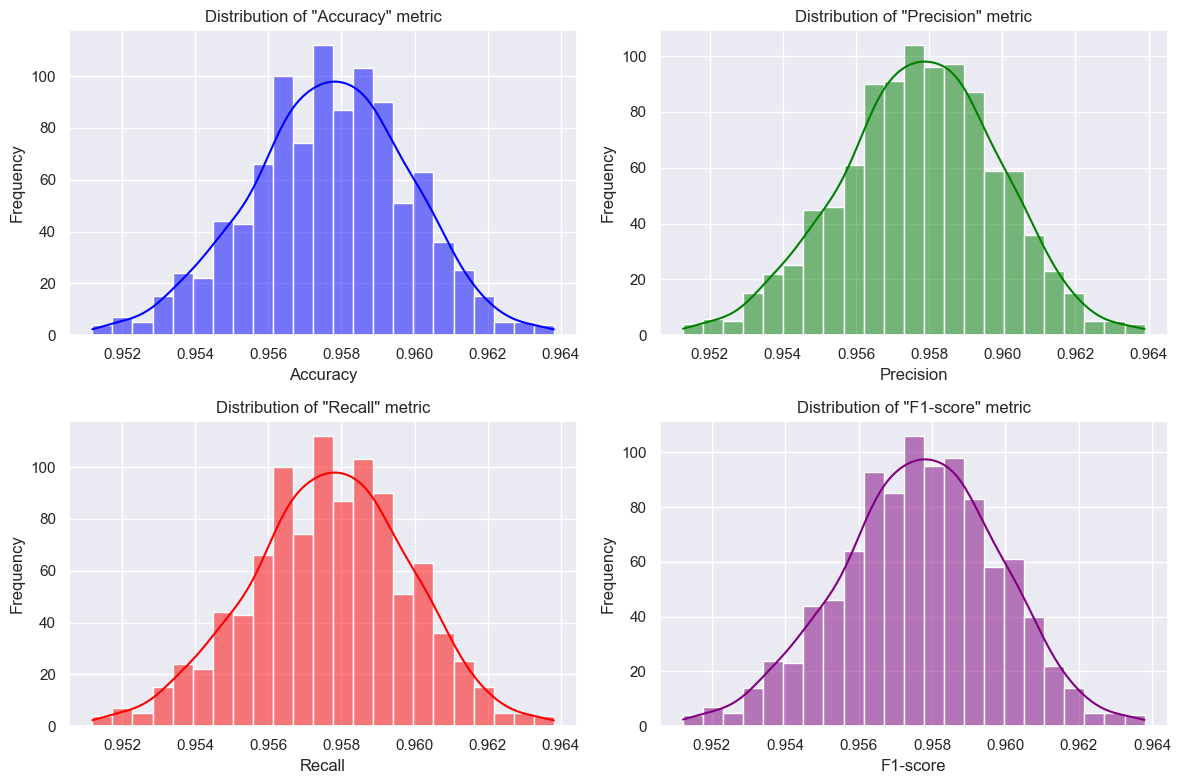

In [33]:
# Metrics distribution visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
metrics = [boot_accuracies, boot_precisions, boot_recalls, boot_f1_scores]
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-score']
colors = ['blue', 'green', 'red', 'purple']

for i, (ax, metric, name, color) in enumerate(zip(
        axes.flat, metrics, metric_names, colors)):
    sns.histplot(metric, ax=ax, color=color, kde=True)
    ax.set_title(f'Distribution of "{name}" metric')
    ax.set_xlabel(name)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Interpreting the best model

Top 10 most important pixels:


,pixel,importance
320,pixel378,0.010568
293,pixel350,0.009475
397,pixel461,0.008172
347,pixel406,0.007963
319,pixel377,0.007834
350,pixel409,0.007810
375,pixel437,0.007550
103,pixel155,0.007217
346,pixel405,0.007087
476,pixel542,0.007055


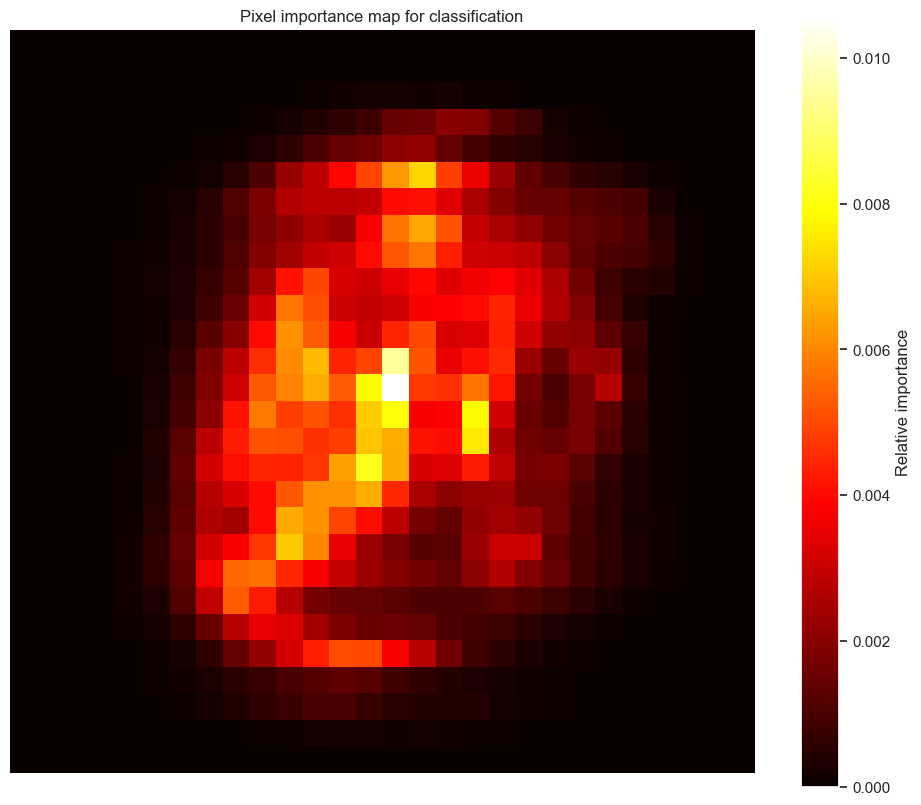

In [34]:
if hasattr(best_model, 'feature_importances_'):
    feature_importance = best_model.feature_importances_

    importance_df = pd.DataFrame({
        'pixel': x_train.columns,
        'importance': feature_importance
    }).sort_values('importance', ascending=False)

    print('Top 10 most important pixels:')
    display(importance_df.head(10))

    # Visualizing important pixels on 28x28 image
    plt.figure(figsize=(12, 10))

    # Creating pixel importance map
    importance_map = np.zeros(28 * 28)

    # Filling important pixels
    for i, (pixel_name, importance) in enumerate(zip(
                x_train.columns, feature_importance)):
        if pixel_name.startswith('pixel'):
            try:
                pixel_idx = int(pixel_name[5:])
                if pixel_idx < len(importance_map):
                    importance_map[pixel_idx] = importance
            except ValueError:
                continue

    # Visualizing pixel importance map
    plt.imshow(importance_map.reshape(28, 28), cmap='hot',
               interpolation='nearest')
    plt.colorbar(label='Relative importance')
    plt.title('Pixel importance map for classification')
    plt.axis('off')
    plt.show()

Model interpretation revealed that the most informative pixels for classification are concentrated in the center of the image, forming clear clusters of significance. It is these areas that make the decisive contribution to the final decision.